In [27]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme(style="whitegrid")

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [28]:
df = pd.read_csv("historical_data.csv")

In [69]:
print("Antal rader:", df.shape[0])
print("Antal kolumner:", df.shape[1])

print("\nDatasetets datatyper:")
print("------------------------------")
print(df.dtypes)

Antal rader: 12000
Antal kolumner: 18

Datasetets datatyper:
------------------------------
id                              int64
day                             int64
event_type                        str
category                          str
region                            str
device                            str
account_age_days              float64
num_prev_listings               int64
prev_reports_30d                int64
verification_level              int64
price                         float64
num_images                      int64
message_length                  int64
contains_off_platform           int64
urgency_words                   int64
payment_attempt                 int64
time_to_first_response_min    float64
is_suspicious                   int64
dtype: object


In [70]:
print("\nSaknade värden per kolumn:")
print("------------------------------")
print(df.isna().sum())


Saknade värden per kolumn:
------------------------------
id                              0
day                             0
event_type                      0
category                        0
region                        340
device                          0
account_age_days                0
num_prev_listings               0
prev_reports_30d                0
verification_level              0
price                         818
num_images                      0
message_length                  0
contains_off_platform           0
urgency_words                   0
payment_attempt                 0
time_to_first_response_min    590
is_suspicious                   0
dtype: int64


In [43]:
print("Target-fördelning:")
print(df["is_suspicious"].value_counts())

print("\nProcentuell fördelning:")
print(df["is_suspicious"].value_counts(normalize=True) * 100)

Target-fördelning:
is_suspicious
0    10776
1     1224
Name: count, dtype: int64

Procentuell fördelning:
is_suspicious
0    89.8
1    10.2
Name: proportion, dtype: float64


In [31]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,12000.0,5999.500000,3464.245950,0.00,2999.750,5999.500,8999.250,11999.00
day,12000.0,7.482667,4.032520,1.00,4.000,7.000,11.000,14.00
account_age_days,12000.0,99.632567,112.903541,2.20,36.300,66.600,120.700,2741.70
num_prev_listings,12000.0,3.027750,1.766467,0.00,2.000,3.000,4.000,12.00
prev_reports_30d,12000.0,0.151500,0.386083,0.00,0.000,0.000,0.000,3.00
verification_level,12000.0,0.710167,0.719171,0.00,0.000,1.000,1.000,2.00
price,11182.0,207.348603,196.226023,7.67,86.195,149.225,256.795,2743.08
num_images,12000.0,2.870417,1.766886,0.00,2.000,3.000,4.000,10.00
message_length,12000.0,111.154417,66.396885,0.00,63.000,108.000,155.000,416.00
contains_off_platform,12000.0,0.072833,0.259874,0.00,0.000,0.000,0.000,1.00


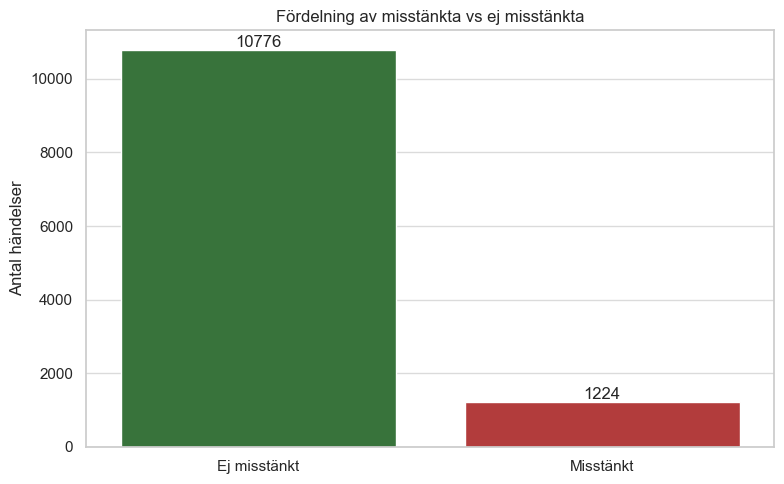

In [68]:
counts = df["is_suspicious"].value_counts(normalize=True) * 100

plt.figure(figsize=(8,5))
ax = sns.countplot(x="is_suspicious", hue="is_suspicious", data=df, palette=["#2E7D32", "#C62828"], legend=False)
plt.title("Fördelning av misstänkta vs ej misstänkta")
plt.xlabel("")
plt.ylabel("Antal händelser")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Ej misstänkt", "Misstänkt"])

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.grid(True, axis="y", alpha=0.7)
plt.tight_layout()
plt.show()

In [59]:
numeric_cols = df.select_dtypes(include=np.number)
correlations = numeric_cols.corr()["is_suspicious"].sort_values(ascending=False)

top_corr = correlations.drop("is_suspicious")

top_corr = top_corr.reindex(top_corr.abs().sort_values(ascending=False).index)
top_5 = top_corr.head(5)

print("Korrelation med is_suspicious:")
print("----------------------------------")
print(top_5)

Korrelation med is_suspicious:
----------------------------------
contains_off_platform    0.141828
prev_reports_30d         0.130920
account_age_days        -0.103146
verification_level      -0.100409
urgency_words            0.087295
Name: is_suspicious, dtype: float64


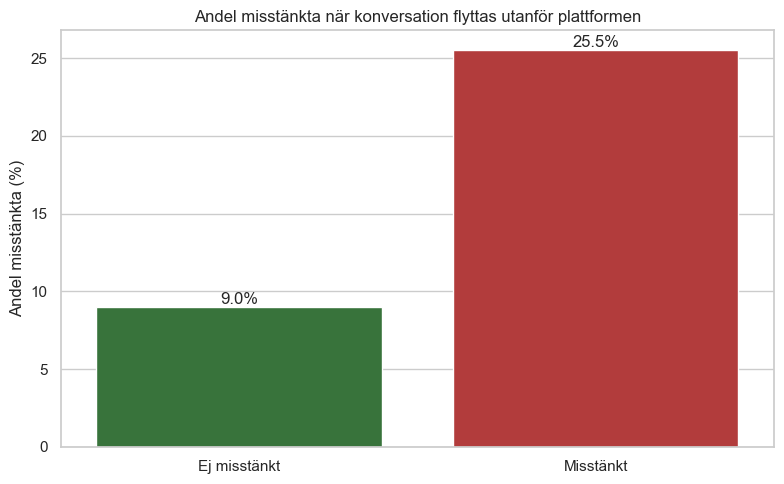

In [67]:
cross_tab = pd.crosstab(
    df["contains_off_platform"],
    df["is_suspicious"],
    normalize="index"
) * 100

risk_percent = cross_tab[1]

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=risk_percent.index, hue=risk_percent.index,
    y=risk_percent.values, palette=["#2E7D32", "#C62828"], legend=False
)

plt.title("Andel misstänkta när konversation flyttas utanför plattformen")
plt.xlabel("")
plt.ylabel("Andel misstänkta (%)")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Ej misstänkt", "Misstänkt"])

for i, v in enumerate(risk_percent.values):
    plt.text(i, v, f"{v:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

## Insikter
- Modellen/policyn ska fokusera på en minoritet med hög risk då datasetet är obalanserat.  
- Risken är mycket högre när användaren försöker flytta konversationen utanför plattformen (25.5%). Detta är en tydlig signal som kan användas för prioritering. 